# Session 5: Practical Assessment – Advanced Anomaly Detection

**Course:** Machine Learning III (Unsupervised Learning) @Albert School  
**Format:** Groups of 1 to 3 students.  
**Duration:** 3 hours (Due at the end of the session).  
**Grading:** Graded (Low-impact, incentive-based).

### 📖 The Business Scenario
You are the Lead Data Science team for a major manufacturing firm. The company operates expensive, heavy machinery that occasionally suffers from catastrophic failures, halting production and costing **€100,000 per hour** of downtime. 

Your operations team has provided you with telemetry data from these machines (temperatures, torque, tool wear, etc.). Standard rules-based monitoring is no longer sufficient. Your objective is to build an unsupervised anomaly detection pipeline to flag potential machine failures *before* they occur, while minimizing "Alert Fatigue" (False Positives) for the maintenance crew.

### 🎯 Instructions & Deliverables
You must complete this notebook by addressing two distinct perspectives: the **Technical Data Scientist** and the **Business Manager**.

1. **Part 1: Exploratory Data Analysis (EDA) & Cleaning**
   - Investigate features, missing values, and distributions.
   - Preprocess the data (Standardization, handling categorical variables like `Type`).
2. **Part 2: Modeling & Hyperparameter Tuning**
   - Train 4 models: `IsolationForest`, `OneClassSVM`, `LocalOutlierFactor`, and `EllipticEnvelope`.
   - **Rule:** You must tune the trade-off parameters (`contamination`, `nu`, etc.) and justify your choices.
3. **Part 3: Technical Comparison & Visualizations**
   - Use PCA or t-SNE to project the data into 2D/3D.
   - Overlay the anomalies flagged by your models. 
   - Deep Dive: Isolate specific machines flagged by LOF but missed by iForest (or vice versa) and explain *why* based on the algorithm's mathematical assumptions.
4. **Part 4: Managerial Conclusion & Actionable Strategy**
   - **Cost Matrix:** A False Positive costs **€500**. A False Negative costs **€15,000**.
   - Bring back the `Machine failure` labels (hidden during training) and evaluate your models.
   - Conclude: Which model saves the company the most money?


In [15]:
# ==========================================
# 🚀 INITIALIZATION & DATA LOADING
# Run this cell to get started!
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# 1. Load the AI4I 2020 Predictive Maintenance Dataset directly from UCI
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv"
print("Downloading dataset...")
df_raw = pd.read_csv(url)

print(f"Dataset loaded successfully! Shape: {df_raw.shape}")
display(df_raw.head())


URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:997)>

In [ ]:
df_raw = pd.read_csv("ai4i2020.csv")

---
## Part 1: Exploratory Data Analysis (EDA) & Cleaning
*(Your code and analysis here. Think about standardization and how to handle the `Type` column!)*


In [ ]:
# ==========================================
# 1.1  INITIAL EXPLORATION
# ==========================================

print("="*60)
print("DATASET OVERVIEW")
print("="*60)
print(f"\nShape: {df_raw.shape}")
print(f"\nColumn types:\n{df_raw.dtypes}")

print("\n" + "="*60)
print("FIRST 5 ROWS")
print("="*60)
display(df_raw.head())

print("\n" + "="*60)
print("DESCRIPTIVE STATISTICS")
print("="*60)
display(df_raw.describe())

print("\n" + "="*60)
print("MISSING VALUES")
print("="*60)
missing = df_raw.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "No missing values found.")

print("\n" + "="*60)
print("CLASS DISTRIBUTION – Machine failure (label, hidden later)")
print("="*60)
print(df_raw["Machine failure"].value_counts())
print(f"\nFailure rate: {df_raw['Machine failure'].mean()*100:.2f}%")


DATASET OVERVIEW

Shape: (10000, 14)

Column types:
UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Machine failure              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
dtype: object

FIRST 5 ROWS


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0



DESCRIPTIVE STATISTICS


,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000



MISSING VALUES
No missing values found.

CLASS DISTRIBUTION – Machine failure (label, hidden later)
Machine failure
0    9661
1     339
Name: count, dtype: int64

Failure rate: 3.39%


In [16]:
# ==========================================
# 1.2  FEATURE SEPARATION
# ==========================================
# UDI and Product ID are identifiers – useless for anomaly detection.
# Machine failure + failure-mode flags (TWF, HDF, PWF, OSF, RNF) are
# LABELS we must hide during unsupervised training and bring back in Part 4.

label_cols = ["Machine failure", "TWF", "HDF", "PWF", "OSF", "RNF"]
id_cols    = ["UDI", "Product ID"]

y_true = df_raw["Machine failure"].copy()

df = df_raw.drop(columns=id_cols + label_cols)
print(f"Working feature set: {list(df.columns)}")
print(f"Shape after dropping IDs & labels: {df.shape}")
display(df.head())

Working feature set: ['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
Shape after dropping IDs & labels: (10000, 6)


,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
0,M,298.1,308.6,1551,42.8,0
1,L,298.2,308.7,1408,46.3,3
2,L,298.1,308.5,1498,49.4,5
3,L,298.2,308.6,1433,39.5,7
4,L,298.2,308.7,1408,40.0,9


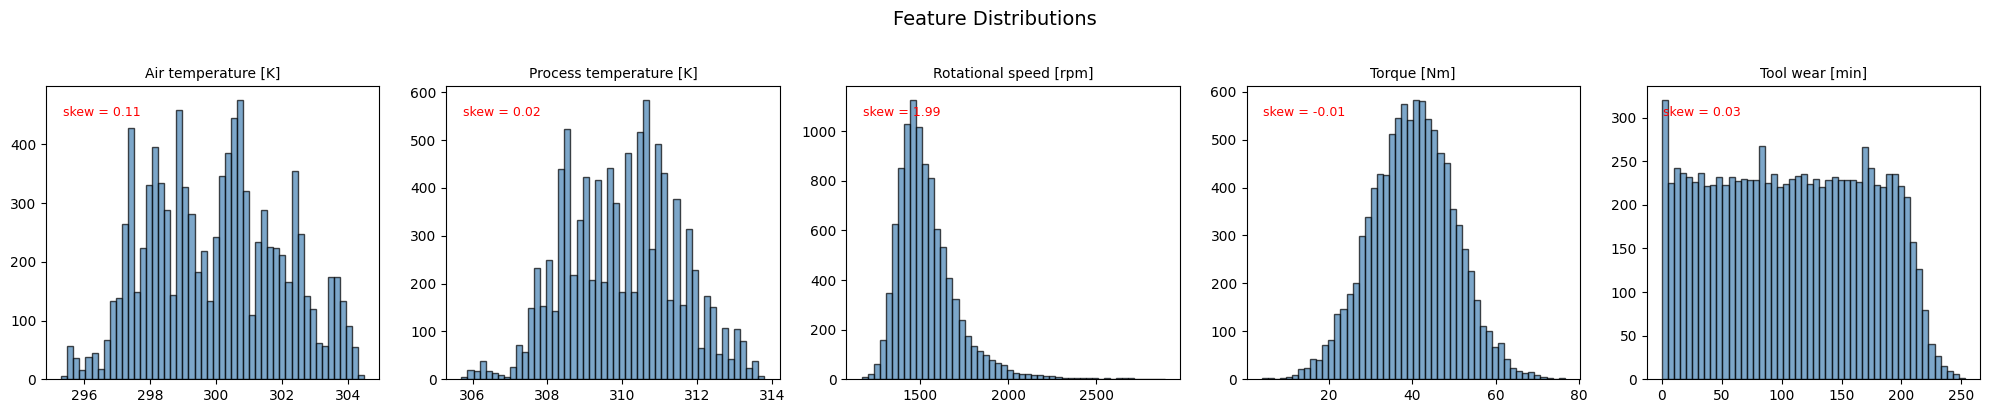


Skewness summary:
  Air temperature [K]                  skew=+0.11  ✓ OK
  Process temperature [K]              skew=+0.02  ✓ OK
  Rotational speed [rpm]               skew=+1.99  ⚠ Skewed
  Torque [Nm]                          skew=-0.01  ✓ OK
  Tool wear [min]                      skew=+0.03  ✓ OK


In [17]:
# ==========================================
# 1.3  DISTRIBUTION ANALYSIS – Skewness & Histograms
# ==========================================

numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

fig, axes = plt.subplots(1, len(numerical_cols), figsize=(20, 4))
for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=50, edgecolor="k", alpha=0.7, color="steelblue")
    axes[i].set_title(col, fontsize=10)
    skew_val = df[col].skew()
    axes[i].annotate(f"skew = {skew_val:.2f}", xy=(0.05, 0.90),
                     xycoords="axes fraction", fontsize=9, color="red")
fig.suptitle("Feature Distributions", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\nSkewness summary:")
for col in numerical_cols:
    s = df[col].skew()
    tag = "✓ OK" if abs(s) < 1 else "⚠ Skewed"
    print(f"  {col:35s}  skew={s:+.2f}  {tag}")

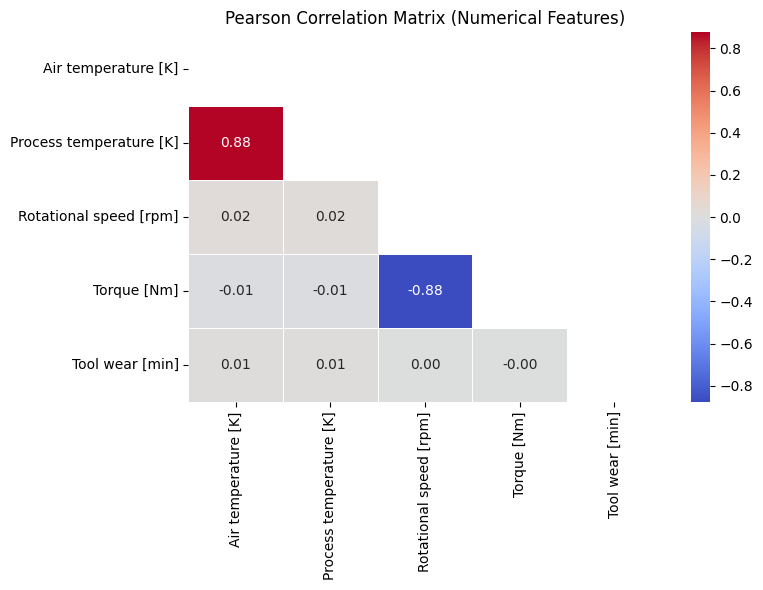


Key observations:
• Air temperature & Process temperature are positively correlated (~0.88).
  → This is expected: the process heats up proportionally to ambient temp.
• Torque and Rotational speed show negative correlation (~−0.88).
  → Higher torque → lower RPM (physics of the motor).
• Tool wear is largely independent of the other sensors.


In [18]:
# ==========================================
# 1.4  CORRELATION MATRIX
# ==========================================

fig, ax = plt.subplots(figsize=(8, 6))
corr = df[numerical_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, ax=ax)
ax.set_title("Pearson Correlation Matrix (Numerical Features)")
plt.tight_layout()
plt.show()

print("\nKey observations:")
print("• Air temperature & Process temperature are positively correlated (~0.88).")
print("  → This is expected: the process heats up proportionally to ambient temp.")
print("• Torque and Rotational speed show negative correlation (~−0.88).")
print("  → Higher torque → lower RPM (physics of the motor).")
print("• Tool wear is largely independent of the other sensors.")

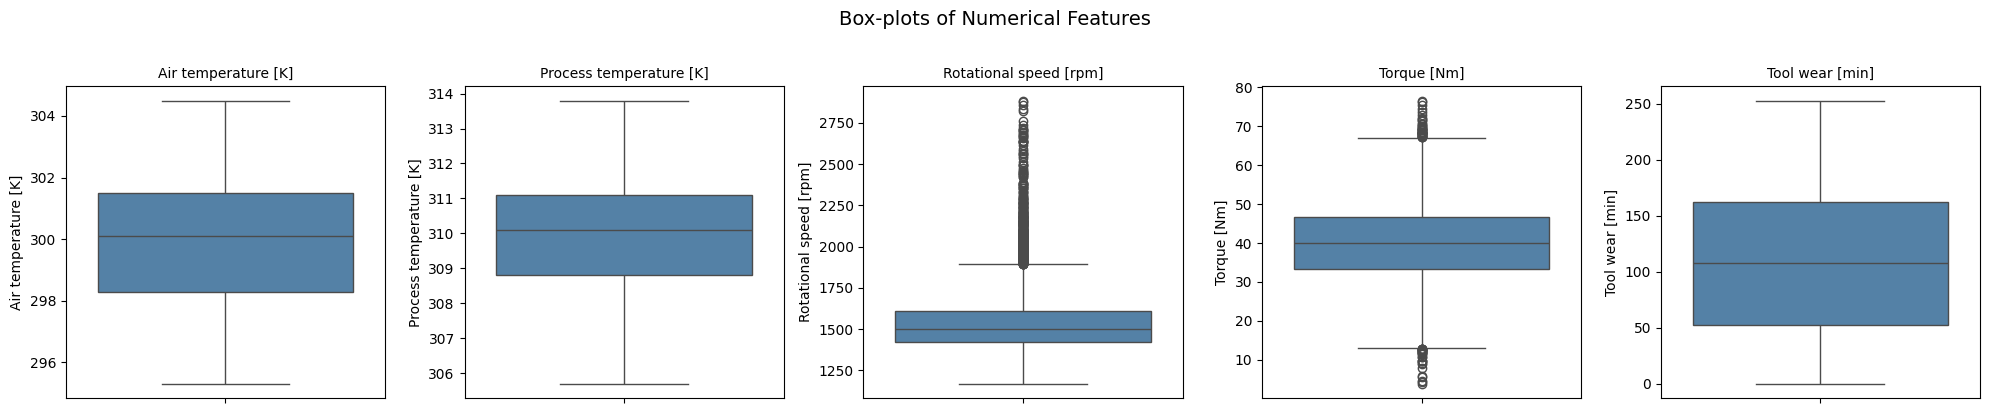

In [19]:
# ==========================================
# 1.5  BOX-PLOTS – quick outlier visual check
# ==========================================

fig, axes = plt.subplots(1, len(numerical_cols), figsize=(20, 4))
for i, col in enumerate(numerical_cols):
    sns.boxplot(y=df[col], ax=axes[i], color="steelblue")
    axes[i].set_title(col, fontsize=10)
fig.suptitle("Box-plots of Numerical Features", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

Unique values in 'Type': ['M' 'L' 'H']

Value counts:
Type
L    6000
M    2997
H    1003
Name: count, dtype: int64


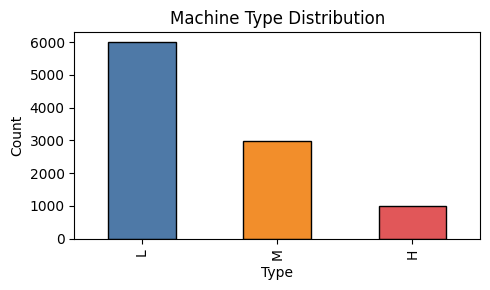

In [20]:
# ==========================================
# 1.6  CATEGORICAL FEATURE – Type
# ==========================================

print("Unique values in 'Type':", df["Type"].unique())
print("\nValue counts:")
print(df["Type"].value_counts())

fig, ax = plt.subplots(figsize=(5, 3))
df["Type"].value_counts().plot.bar(ax=ax, color=["#4e79a7", "#f28e2b", "#e15759"],
                                   edgecolor="k")
ax.set_title("Machine Type Distribution")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

### 1.7 — Preprocessing: Why Standardisation Matters

**Distance-based methods (LOF, Elliptic Envelope, OneClassSVM with RBF kernel):**

These algorithms measure proximity between data points — either through Euclidean distances (LOF), Mahalanobis distances (Elliptic Envelope), or kernel-space dot products (SVM/RBF).  
If features live on vastly different scales (e.g. *Rotational speed* ≈ 1300–2900 rpm vs. *Torque* ≈ 3–77 Nm), the high-magnitude feature will dominate the distance computation and the smaller-magnitude features will be effectively ignored.  
**Standardisation (zero mean, unit variance) puts every feature on an equal footing**, ensuring each one contributes proportionally to the distance metric.

**Isolation Forest — why scaling is *not* strictly required:**

Isolation Forest isolates anomalies by randomly selecting a feature and then randomly selecting a split value between the min and max of that feature. Because it only performs **axis-aligned splits and compares values within a single feature at a time**, the absolute scale of each feature is irrelevant — a split on *Rotational speed* (large numbers) never interacts arithmetically with a split on *Torque* (small numbers).  
Standardisation therefore does not change the tree structure or the anomaly scores. It is harmless to apply, but not necessary.

---

### 1.8 — Handling the Categorical Feature `Type`

The `Type` column takes three values: **L** (Low), **M** (Medium), **H** (High quality).  

For **distance-based algorithms** we cannot feed in a raw categorical string — distances are undefined on strings. Two common strategies:

| Strategy | Pros | Cons |
|---|---|---|
| **One-Hot Encoding** (3 binary columns) | No artificial ordering; works with any algorithm | Adds dimensions; Hamming-like distances on binary axes |
| **Ordinal Encoding** (H→0, M→1, L→2) | Single column; preserves a natural quality ordering | Assumes equal spacing between levels |

We choose **One-Hot Encoding** because it avoids imposing an arbitrary numeric gap between quality levels, and the extra 2 dimensions are negligible relative to the 5 numerical features. The one-hot columns are left unscaled (they are already 0/1) so distance-based methods treat them as equal-weight binary indicators.

In [21]:
# ==========================================
# 1.9  PREPROCESSING PIPELINE
# ==========================================
from sklearn.preprocessing import StandardScaler

# --- One-Hot Encode 'Type' ---
df_encoded = pd.get_dummies(df, columns=["Type"], prefix="Type", drop_first=False)
print("Columns after one-hot encoding:", list(df_encoded.columns))

# --- Standardise numerical features only ---
scaler = StandardScaler()
df_scaled = df_encoded.copy()
df_scaled[numerical_cols] = scaler.fit_transform(df_encoded[numerical_cols])

print("\nAfter standardisation (first 5 rows):")
display(df_scaled.head())
print(f"\nFinal preprocessed shape: {df_scaled.shape}")
print("Means (should be ~0):\n", df_scaled[numerical_cols].mean().round(6).to_string())
print("\nStds  (should be ~1):\n", df_scaled[numerical_cols].std().round(4).to_string())

Columns after one-hot encoding: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Type_H', 'Type_L', 'Type_M']

After standardisation (first 5 rows):


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Type_H,Type_L,Type_M
0,-0.952389,-0.947360,0.068185,0.282200,-1.695984,False,False,True
1,-0.902393,-0.879959,-0.729472,0.633308,-1.648852,False,True,False
2,-0.952389,-1.014761,-0.227450,0.944290,-1.617430,False,True,False
3,-0.902393,-0.947360,-0.590021,-0.048845,-1.586009,False,True,False
4,-0.902393,-0.879959,-0.729472,0.001313,-1.554588,False,True,False



Final preprocessed shape: (10000, 8)
Means (should be ~0):
 Air temperature [K]       -0.0
Process temperature [K]   -0.0
Rotational speed [rpm]    -0.0
Torque [Nm]                0.0
Tool wear [min]            0.0

Stds  (should be ~1):
 Air temperature [K]        1.0001
Process temperature [K]    1.0001
Rotational speed [rpm]     1.0001
Torque [Nm]                1.0001
Tool wear [min]            1.0001


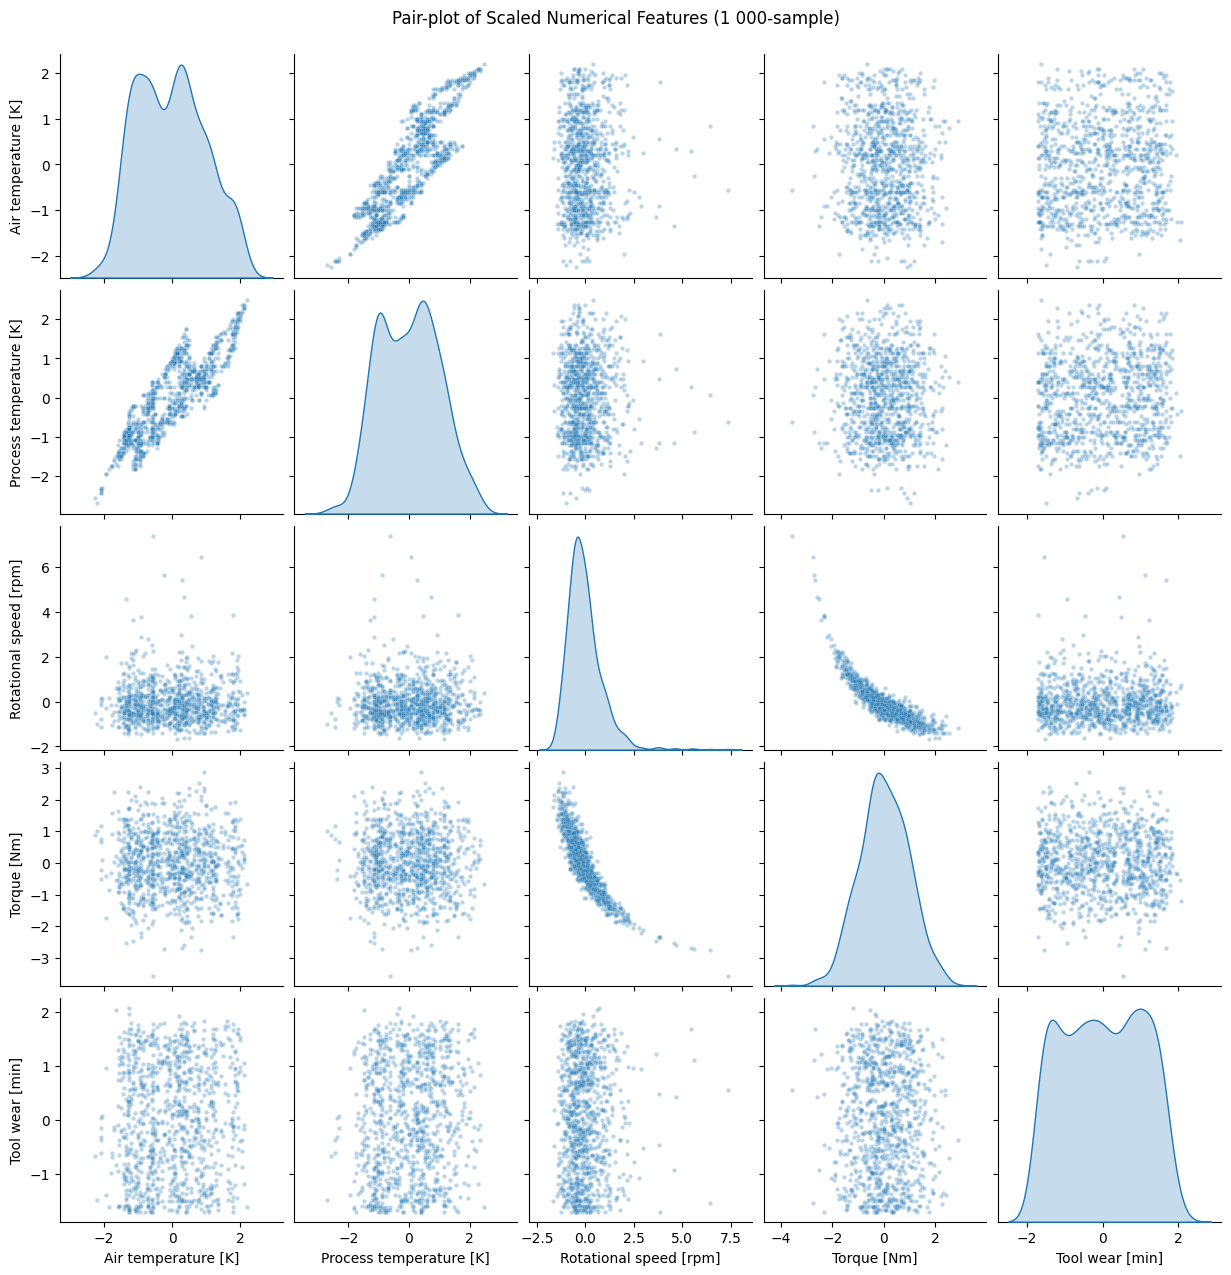


✅ Part 1 complete — preprocessed DataFrame 'df_scaled' is ready for modelling.


In [22]:
# ==========================================
# 1.10  QUICK SANITY CHECK – Pair-plot on scaled data
# ==========================================

sample = df_scaled[numerical_cols].sample(n=min(1000, len(df_scaled)), random_state=42)
g = sns.pairplot(sample, diag_kind="kde", plot_kws={"alpha": 0.3, "s": 10})
g.figure.suptitle("Pair-plot of Scaled Numerical Features (1 000-sample)", y=1.02)
plt.show()

print("\n✅ Part 1 complete — preprocessed DataFrame 'df_scaled' is ready for modelling.")

---
## Part 2: Modeling & Hyperparameter Tuning
*(Train IsolationForest, OneClassSVM, LocalOutlierFactor, and EllipticEnvelope. Remember to tune your threshold parameters!)*


In [23]:
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.neighbors import LocalOutlierFactor
from sklearn.covariance import EllipticEnvelope
from sklearn.preprocessing import StandardScaler

# ==========================================
# PART 2 — TRAIN + TUNE (NO DEFAULT THRESHOLDS)
# ==========================================

# Make this cell runnable even if Part 1 cells were not executed in order.
if "df_scaled" not in globals():
    print("df_scaled not found -> rebuilding minimal preprocessing...")

    if "df_raw" not in globals():
        print("df_raw not found -> downloading dataset...")
        url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00601/ai4i2020.csv"
        df_raw = pd.read_csv(url)
        print(f"Dataset loaded in Part 2 fallback. Shape: {df_raw.shape}")

    label_cols = ["Machine failure", "TWF", "HDF", "PWF", "OSF", "RNF"]
    id_cols = ["UDI", "Product ID"]

    df_tmp = df_raw.drop(columns=id_cols + label_cols).copy()
    num_cols_tmp = df_tmp.select_dtypes(include=np.number).columns.tolist()

    df_encoded = pd.get_dummies(df_tmp, columns=["Type"], prefix="Type", drop_first=False)
    scaler = StandardScaler()
    df_scaled = df_encoded.copy()
    df_scaled[num_cols_tmp] = scaler.fit_transform(df_encoded[num_cols_tmp])

X = df_scaled.values

# EDA insight:
# - Real failures are rare (~3.4% in Part 1)
# - We thus tune around a low anomaly budget (about 2% to 6%)
# - Strong feature correlations exist -> EllipticEnvelope can be useful on Gaussian-like core
TARGET_RATE = 0.034


def to_anomaly_flag(pred):
    """Convert sklearn convention (+1 inlier, -1 outlier) to {0,1} anomaly flag."""
    return (pred == -1).astype(int)


model_flags = {}
model_scores = {}
tuning_rows = []


# ------------------------------------------------------------
# 1) Isolation Forest
# ------------------------------------------------------------
if_grid = [
    {"n_estimators": 300, "max_samples": "auto", "max_features": 0.8, "contamination": c, "random_state": 42}
    for c in [0.02, 0.03, 0.035, 0.04, 0.05]
]

best_if = None
best_if_gap = np.inf

for params in if_grid:
    model = IsolationForest(**params)
    pred = model.fit_predict(X)
    flag = to_anomaly_flag(pred)
    rate = flag.mean()
    gap = abs(rate - TARGET_RATE)

    if gap < best_if_gap:
        best_if_gap = gap
        best_if = (model, params, flag, rate)

if_model, if_params, if_flag, if_rate = best_if
model_flags["IsolationForest"] = if_flag
model_scores["IsolationForest"] = -if_model.score_samples(X)  # higher = more anomalous


# ------------------------------------------------------------
# 2) One-Class SVM
# ------------------------------------------------------------
# nu controls an upper bound on training anomalies and lower bound on support vectors.
ocsvm_grid = [
    {"kernel": "rbf", "gamma": "scale", "nu": nu}
    for nu in [0.02, 0.03, 0.04, 0.05, 0.06]
]

best_svm = None
best_svm_gap = np.inf

for params in ocsvm_grid:
    model = OneClassSVM(**params)
    pred = model.fit_predict(X)
    flag = to_anomaly_flag(pred)
    rate = flag.mean()
    gap = abs(rate - TARGET_RATE)

    if gap < best_svm_gap:
        best_svm_gap = gap
        best_svm = (model, params, flag, rate)

svm_model, svm_params, svm_flag, svm_rate = best_svm
model_flags["OneClassSVM"] = svm_flag
model_scores["OneClassSVM"] = -svm_model.score_samples(X)


# ------------------------------------------------------------
# 3) Local Outlier Factor (LOF)
# ------------------------------------------------------------
# n_neighbors tuned because EDA suggests local heterogeneity (Type mix + skewed sensors).
lof_grid = [
    {"n_neighbors": k, "contamination": c, "metric": "euclidean", "novelty": True}
    for k in [15, 25, 35, 50]
    for c in [0.03, 0.04, 0.05]
]

best_lof = None
best_lof_gap = np.inf

for params in lof_grid:
    model = LocalOutlierFactor(**params)
    model.fit(X)
    pred = model.predict(X)
    flag = to_anomaly_flag(pred)
    rate = flag.mean()
    gap = abs(rate - TARGET_RATE)

    if gap < best_lof_gap:
        best_lof_gap = gap
        best_lof = (model, params, flag, rate)

lof_model, lof_params, lof_flag, lof_rate = best_lof
model_flags["LOF"] = lof_flag
model_scores["LOF"] = -lof_model.score_samples(X)


# ------------------------------------------------------------
# 4) Robust Covariance (Elliptic Envelope)
# ------------------------------------------------------------
# EDA showed correlated temperatures and a central cloud with outlier tails.
ee_grid = [
    {"contamination": c, "support_fraction": sf, "random_state": 42}
    for c in [0.02, 0.03, 0.04, 0.05]
    for sf in [0.8, 0.9, None]
]

best_ee = None
best_ee_gap = np.inf

for params in ee_grid:
    model = EllipticEnvelope(**params)
    pred = model.fit_predict(X)
    flag = to_anomaly_flag(pred)
    rate = flag.mean()
    gap = abs(rate - TARGET_RATE)

    if gap < best_ee_gap:
        best_ee_gap = gap
        best_ee = (model, params, flag, rate)

ee_model, ee_params, ee_flag, ee_rate = best_ee
model_flags["EllipticEnvelope"] = ee_flag
model_scores["EllipticEnvelope"] = -ee_model.score_samples(X)


# ------------------------------------------------------------
# Consolidated outputs for Part 3 / Part 4
# ------------------------------------------------------------
pred_df = pd.DataFrame(model_flags)
score_df = pd.DataFrame(model_scores)

for name, params, rate in [
    ("IsolationForest", if_params, if_rate),
    ("OneClassSVM", svm_params, svm_rate),
    ("LOF", lof_params, lof_rate),
    ("EllipticEnvelope", ee_params, ee_rate),
]:
    tuning_rows.append({
        "Model": name,
        "Chosen params": str(params),
        "Alert rate": round(rate, 4),
        "Gap vs target (3.4%)": round(abs(rate - TARGET_RATE), 4),
    })

summary_tuning = pd.DataFrame(tuning_rows).sort_values("Gap vs target (3.4%)")

print("\nChosen hyperparameters and resulting anomaly rates:")
display(summary_tuning)

print("\nPreview of anomaly flags (1 = anomaly):")
display(pred_df.head())

print("\n✅ Part 2 complete — objects available:")
print("   - pred_df   (binary anomaly flags per model)")
print("   - score_df  (continuous anomaly scores per model)")
print("   - summary_tuning (selected hyperparameters)")



Chosen hyperparameters and resulting anomaly rates:


,Model,Chosen params,Alert rate,Gap vs target (3.4%)
0,IsolationForest,"{'n_estimators': 300, 'max_samples': 'auto', '...",0.0350,0.0010
2,LOF,"{'n_neighbors': 25, 'contamination': 0.04, 'me...",0.0352,0.0012
3,EllipticEnvelope,"{'contamination': 0.03, 'support_fraction': 0....",0.0300,0.0040
1,OneClassSVM,"{'kernel': 'rbf', 'gamma': 'scale', 'nu': 0.03}",0.0297,0.0043



Preview of anomaly flags (1 = anomaly):


,IsolationForest,OneClassSVM,LOF,EllipticEnvelope
0,0,0,0,0
1,0,0,0,0
2,0,0,0,0
3,0,0,0,0
4,0,0,0,0



✅ Part 2 complete — objects available:
   - pred_df   (binary anomaly flags per model)
   - score_df  (continuous anomaly scores per model)
   - summary_tuning (selected hyperparameters)


---
## Part 3: Technical Comparison & Visualizations
*(Use PCA/t-SNE to visualize the flagged anomalies. Find an anomaly caught by one model but missed by another and explain why.)*


In [ ]:
from sklearn.decomposition import PCA

# Your code here


---
## Part 4: Managerial Conclusion & Business Strategy
*(Bring back `y_true`. Calculate the number of False Positives and False Negatives for each model. Apply the cost matrix. Which model wins?)*


In [ ]:
# Business Cost Matrix
COST_FP = 500     # False Positive: Wasted technician check
COST_FN = 15000   # False Negative: Catastrophic machine breakdown

# Your code here
